### References:
* https://www.kaggle.com/code/bhartiprasad17/customer-churn-prediction
* https://medium.com/@obandoandrew8/machine-learning-for-classification-problems-customer-churn-prediction-ae46c574e60

### Imports

In [158]:
IS_LOCAL=True

In [ ]:
# Common Imports
import os
import math

# Data handling
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

# Vizualisation (Matplotlib, Plotly, Seaborn, etc. )
import seaborn as sns
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

# Scikit-learn imports
from sklearn.base import clone
from sklearn.compose import make_column_transformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             precision_recall_curve, auc)
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler

In [3]:
if not IS_LOCAL:
    !pip install imbalanced-learn xgboost scikit-optimize

In [160]:
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier

# Scikit-optimize imports
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

if not IS_LOCAL:
    import boto3
else:
    from pycaret.classification import setup, compare_models

In [161]:
if IS_LOCAL:
    data_path = os.path.join("..", "data", "Telco-Customer-Churn.csv")
    df = pd.read_csv(data_path)
else:
    s3_client = boto3.client('s3')
    bucket_name = 'customer-churn-training-ie'
    s3_path = 'data/Telco-Customer-Churn.csv'
    local_path = '/tmp/Telco-Customer-Churn.csv'
    s3_client.download_file(bucket_name, s3_path, local_path)
    df = pd.read_csv(local_path)

### Data Cleaning

In [162]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [163]:
df.shape

(7043, 21)

In [164]:
unique_value_columns = df.columns[df.nunique() == df.shape[0]]
print("Features with unique values for each row:", unique_value_columns, end='\n\n')

if len(unique_value_columns) > 0:
    df.drop(columns=unique_value_columns, inplace=True)
    print(f"Removed {len(unique_value_columns)} features with unique values for each row in the dataset")
else:
    print("No features exist with unique values for each row in the dataset")

Features with unique values for each row: Index(['customerID'], dtype='object')

Removed 1 features with unique values for each row in the dataset


In [165]:
one_unique_value_columns = df.columns[df.nunique() == 1]
print("Features with one unique value for the entire dataset:", one_unique_value_columns, end='\n\n')

if len(one_unique_value_columns) > 0:
    df.drop(columns=one_unique_value_columns, inplace=True)
    print(f"Removed {len(one_unique_value_columns)} features with one unique value for the entire dataset")
else:
    print("No features exist with one unique value for the entire dataset")

print("Shape of modified dataframe:", df.shape)

Features with one unique value for the entire dataset: Index([], dtype='object')

No features exist with one unique value for the entire dataset
Shape of modified dataframe: (7043, 20)


In [166]:
null_values = df.isnull().sum()
print("Number of null values per feature:\n")
print(null_values)

Number of null values per feature:

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [167]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [168]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

The total charges column should also show up in the describe method, as the column contained numerical data. The isnull() method returned no null values. This means there could be space characters in the column. We need to remove those rows.

The SeniorCitizen columns shows up as a numeric column with values 0 and 1. But converting it to 'Yes' and 'No' for EDA purposes and better readability in graphs.

In [169]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1:'Yes', 0:'No'})

In [170]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

11

In [171]:
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [172]:
df.shape

(7032, 20)

### EDA

##### Distribution of Churn Rate

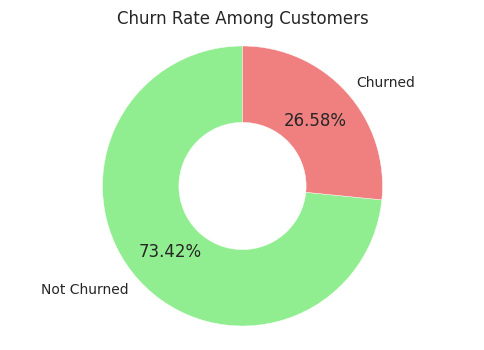

In [173]:
churn_data = df['Churn'].value_counts()
labels = ['Not Churned', 'Churned']
colors = ['lightgreen', 'lightcoral']

plt.figure(figsize=(6, 4))
plt.pie(
    churn_data,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    pctdistance=0.7,
    radius=2.2
)

centre_circle = plt.Circle((0, 0), 1, color='white')
plt.gca().add_artist(centre_circle)

plt.title('Churn Rate Among Customers')
plt.axis('equal')  # Keeps the pie chart as a circle
plt.show()

<span style="color:lime">Clearly the target variable is imbalanced.<span>

##### Correlation Matrix

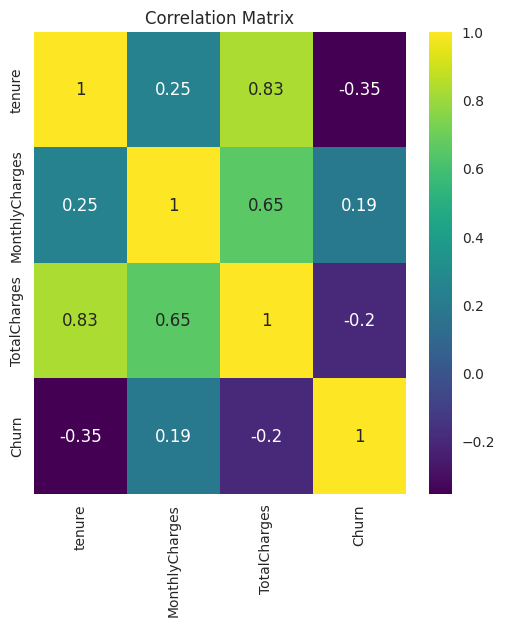

In [174]:
numeric_columns = df.select_dtypes(include=['number'])
numeric_columns['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
plt.figure(figsize=(6,6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

<span style="color:lime">

* As 'tenure' increases, the 'Churn' rate tends to decrease.

* As 'MonthlyCharges' increase, the 'Churn' rate tends to slightly increase. However, the correlation is not as strong as with 'tenure'.

* As 'TotalCharges' increases, the 'Churn' rate tends to slightly decrease.
<span>

##### KDE Plot

In [175]:
def kdeplots_for_numerical_features(df, numeric_columns, target_column):

    num_cols = 2
    num_rows = math.ceil(len(numeric_columns) / num_cols)
    
    fig = plt.figure(figsize=(12, 5 * num_rows))
    
    for idx, col in enumerate(numeric_columns, 1):
        ax = fig.add_subplot(num_rows, num_cols, idx)
        sns.kdeplot(data=df[df[target_column] == "Yes"], x=col, fill=True, label="Churn", ax=ax, color="red")
        sns.kdeplot(data=df[df[target_column] == "No"], x=col, fill=True, label="No Churn", ax=ax, color="green")
        
        ax.set_title(col)
        ax.legend(loc='upper right')

    plt.tight_layout()
    return plt.show()

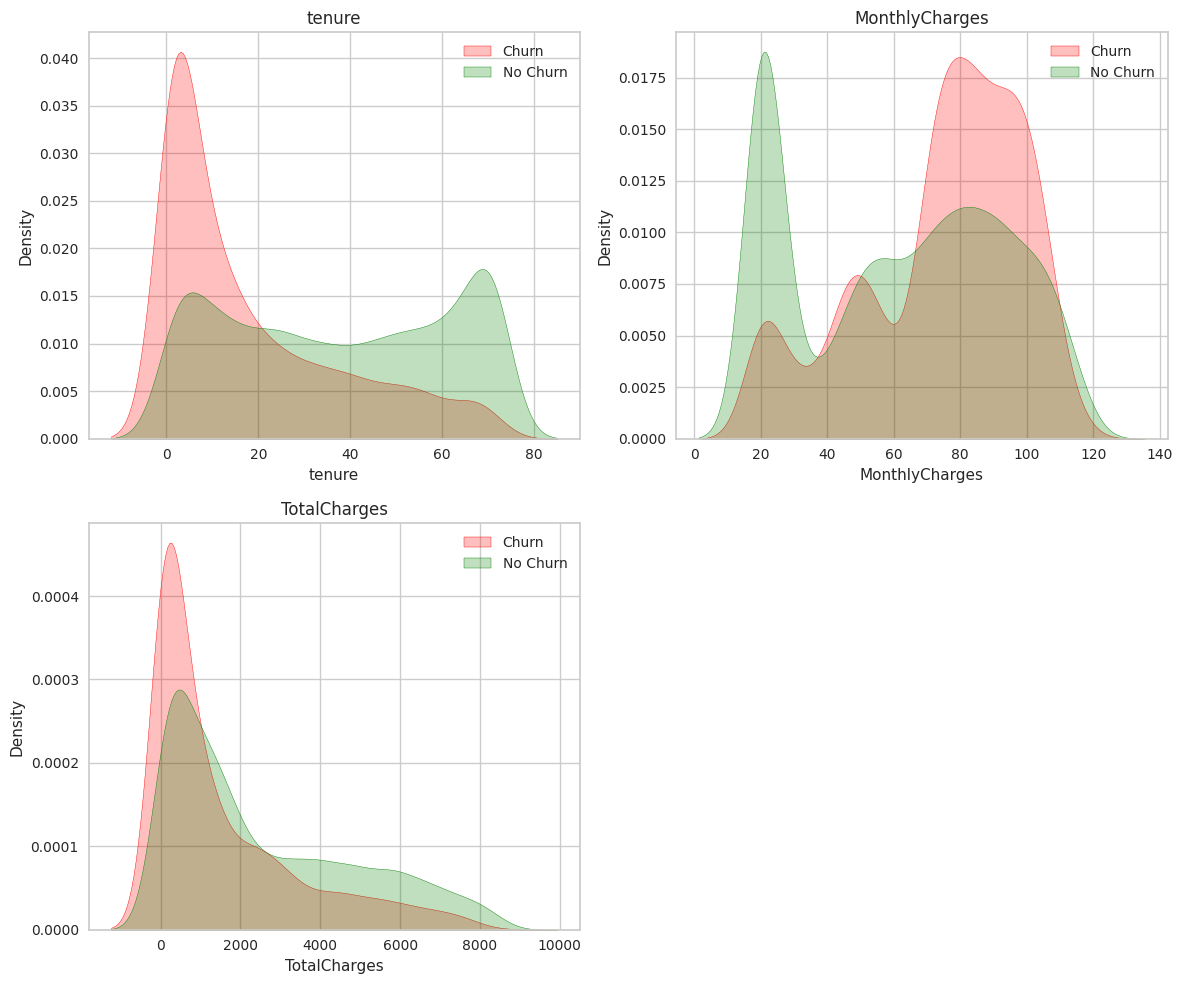

In [176]:
numeric_columns = df.select_dtypes(include='number').columns
kdeplots_for_numerical_features(df, numeric_columns, "Churn")

<span style="color:lime">

* Customers with short tenure are more likely to churn.

* Customers who paid more on monthly charges have higher churn rates.

<span>

##### Box Plot

In [177]:
def plot_boxplots(df, numeric_columns):

    num_cols = 2
    num_rows = math.ceil(len(numeric_columns) / num_cols)
    
    fig = plt.figure(figsize=(12, 5 * num_rows))
    
    for idx, col in enumerate(numeric_columns, 1):
        ax = fig.add_subplot(num_rows, num_cols, idx)
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(f"Boxplot for {col}")

    plt.tight_layout()
    plt.show()

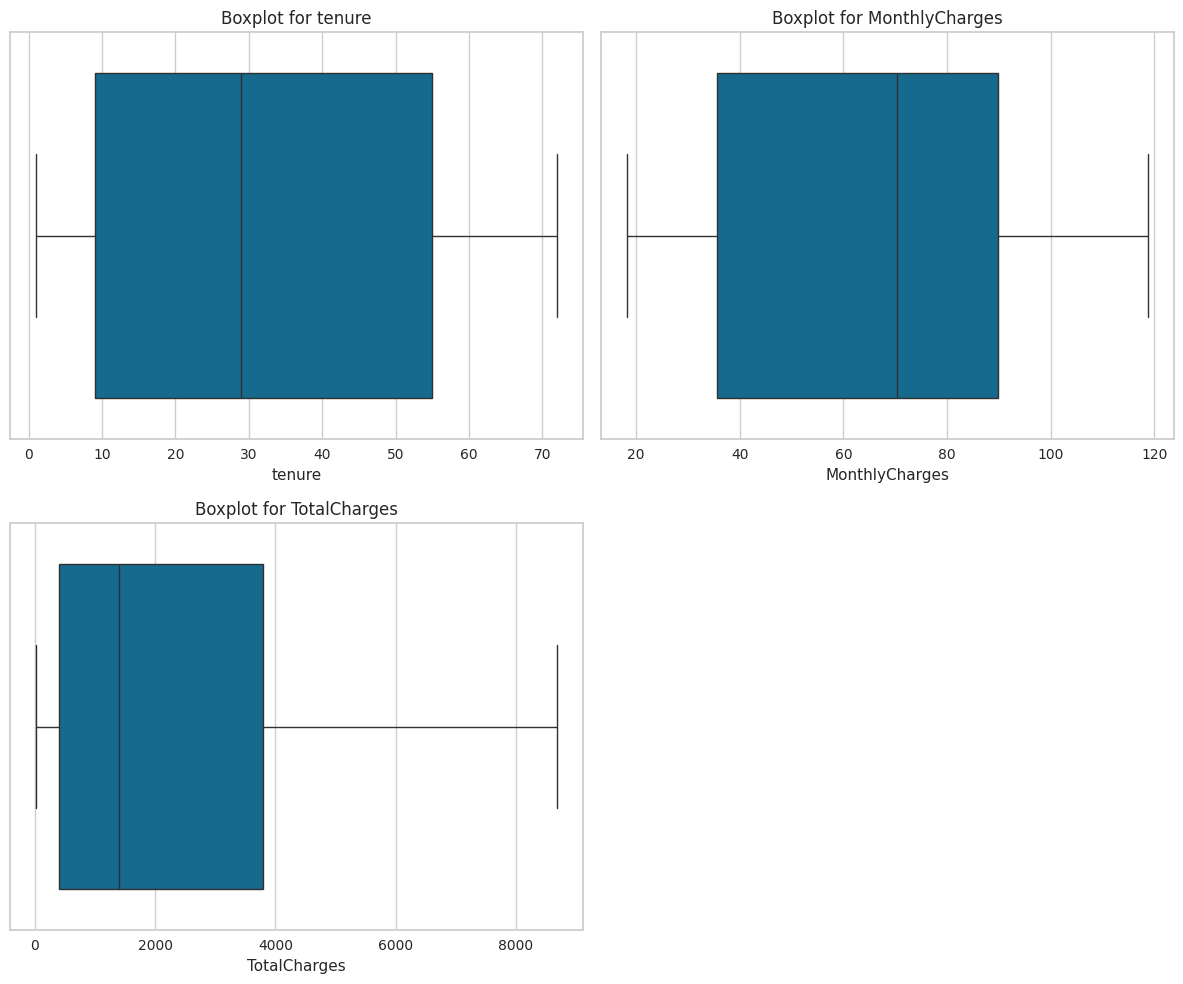

In [178]:
plot_boxplots(df,numeric_columns)

<span style="color:lime"> Conclusion: Numerical variables doesn’t have any outliers. <span>

##### Count Plots

In [179]:
def countplots_for_categorical_features(df, categorical_columns, target_column):

    num_cols = 2
    num_rows = math.ceil(len(categorical_columns) / num_cols)
    
    fig = plt.figure(figsize=(12, 5 * num_rows))
    
    for idx, col in enumerate(categorical_columns, 1):
        ax = fig.add_subplot(num_rows, num_cols, idx)
        sns.countplot(x=col, data=df, hue=target_column, palette=['lightgreen', 'lightcoral'], ax=ax)
        ax.set_title(f"Churn Distribution by {col}")
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    return plt.show()

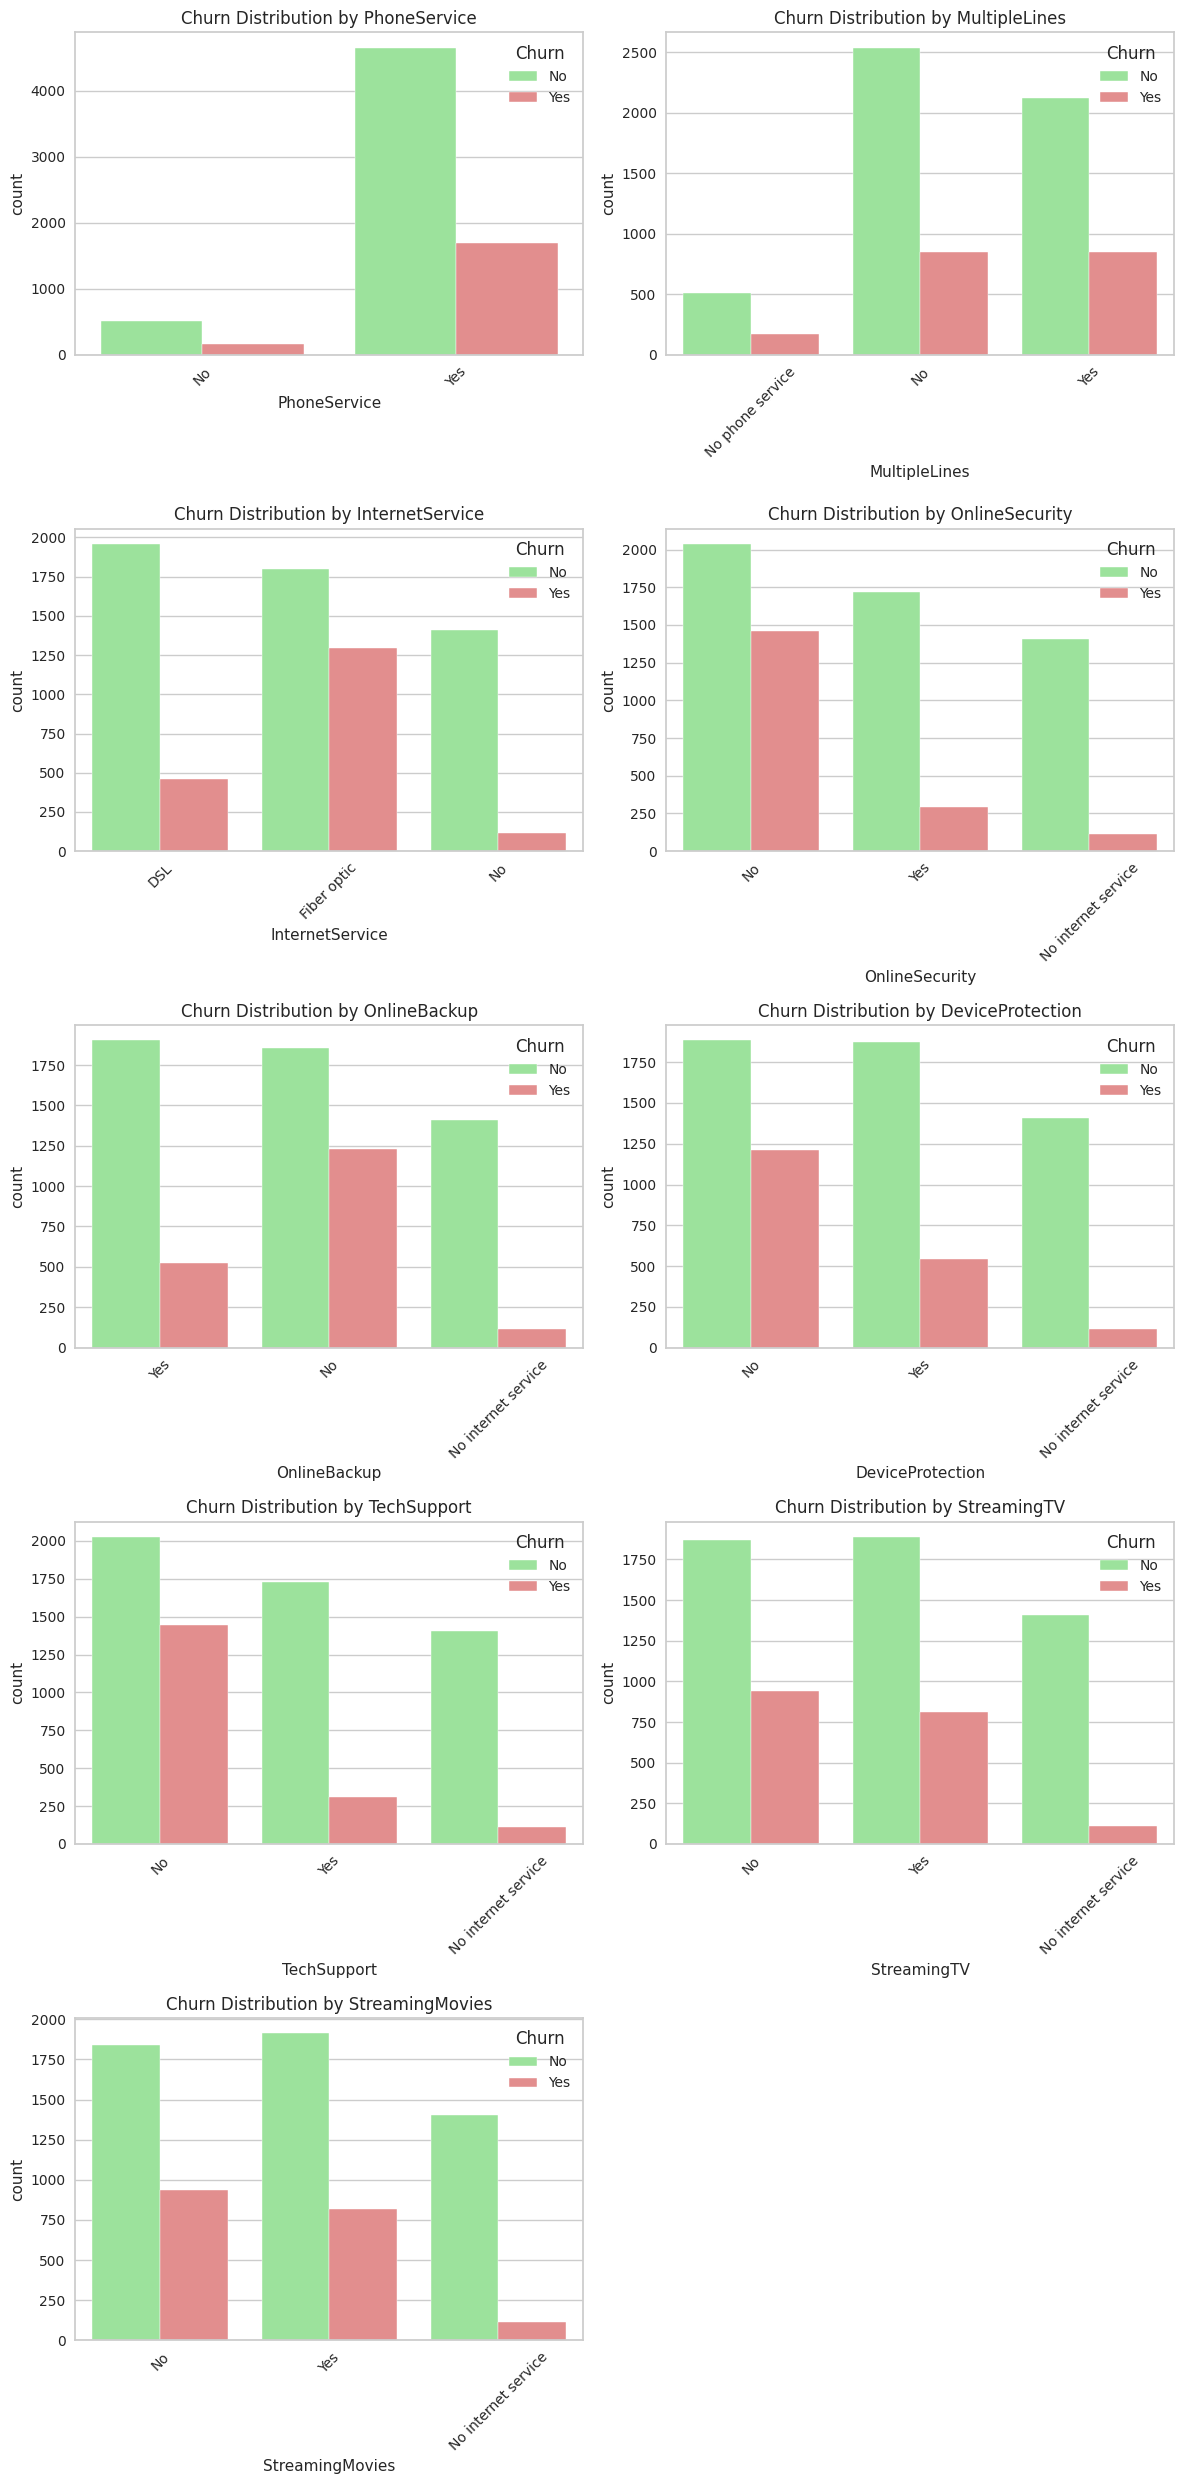

In [180]:
customer_services = ["PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

countplots_for_categorical_features(df, customer_services, "Churn")

<span style="color:lime">

* Moderately higher churn rate for customers who has the phone service.

* Customers with internet service fiber optic have a higher churn rate compared with DSL and No.

* The much higher churn rate for customers without online security.

* Customers who don’t have access to tech support tend to leave more frequently than those who do.

* Customers without online backup and device protection have a higher churn rate.

<span>

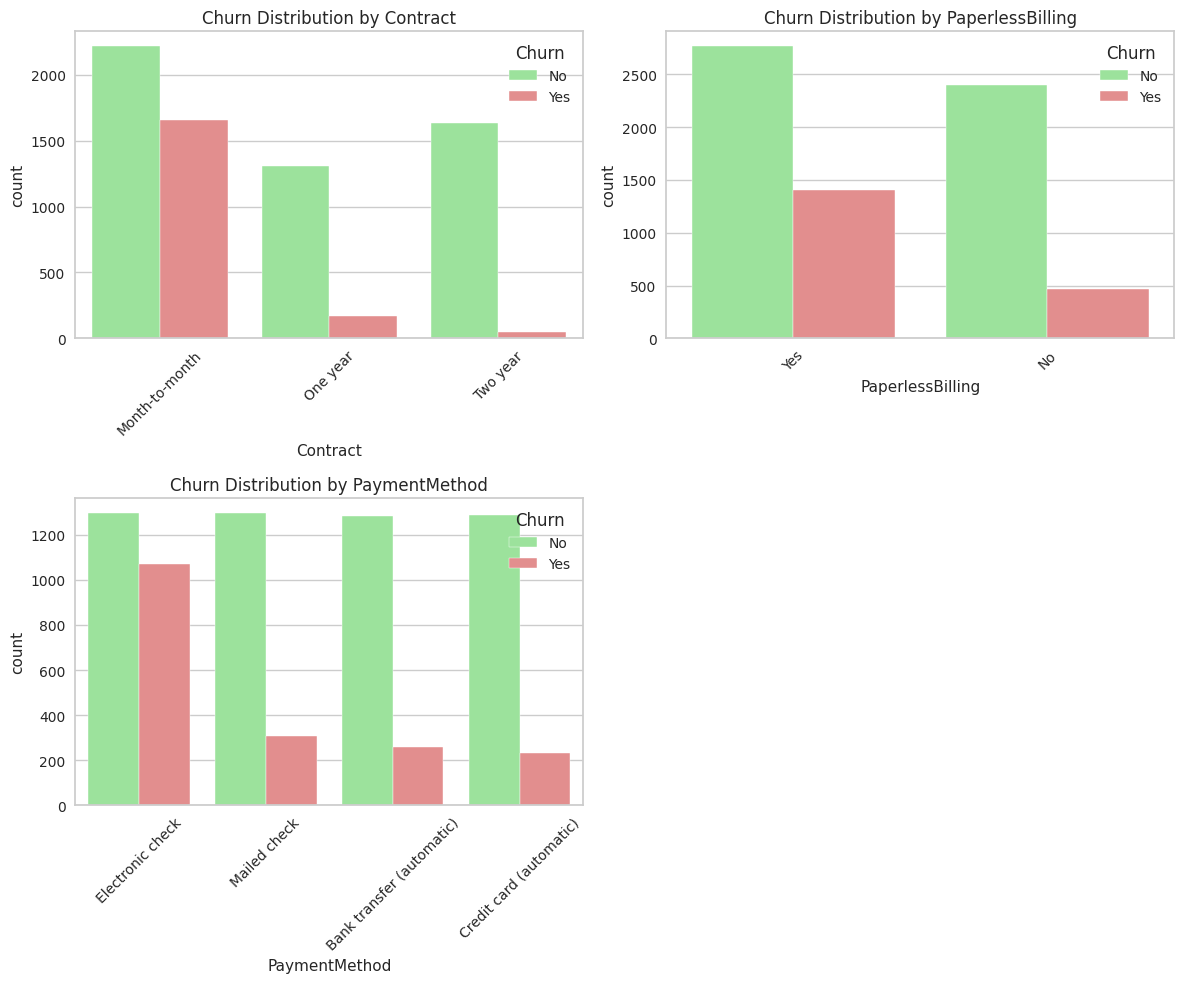

In [181]:
customer_account_cat = ["Contract", "PaperlessBilling", "PaymentMethod"]
countplots_for_categorical_features(df, customer_account_cat, "Churn")

<span style="color:lime">

* Customers are more likely to churn with month-to-month contracts.

* Moderately higher churn rate with electronic check payment method.

* Customers with paperless billing have higher churn rates.

<span>

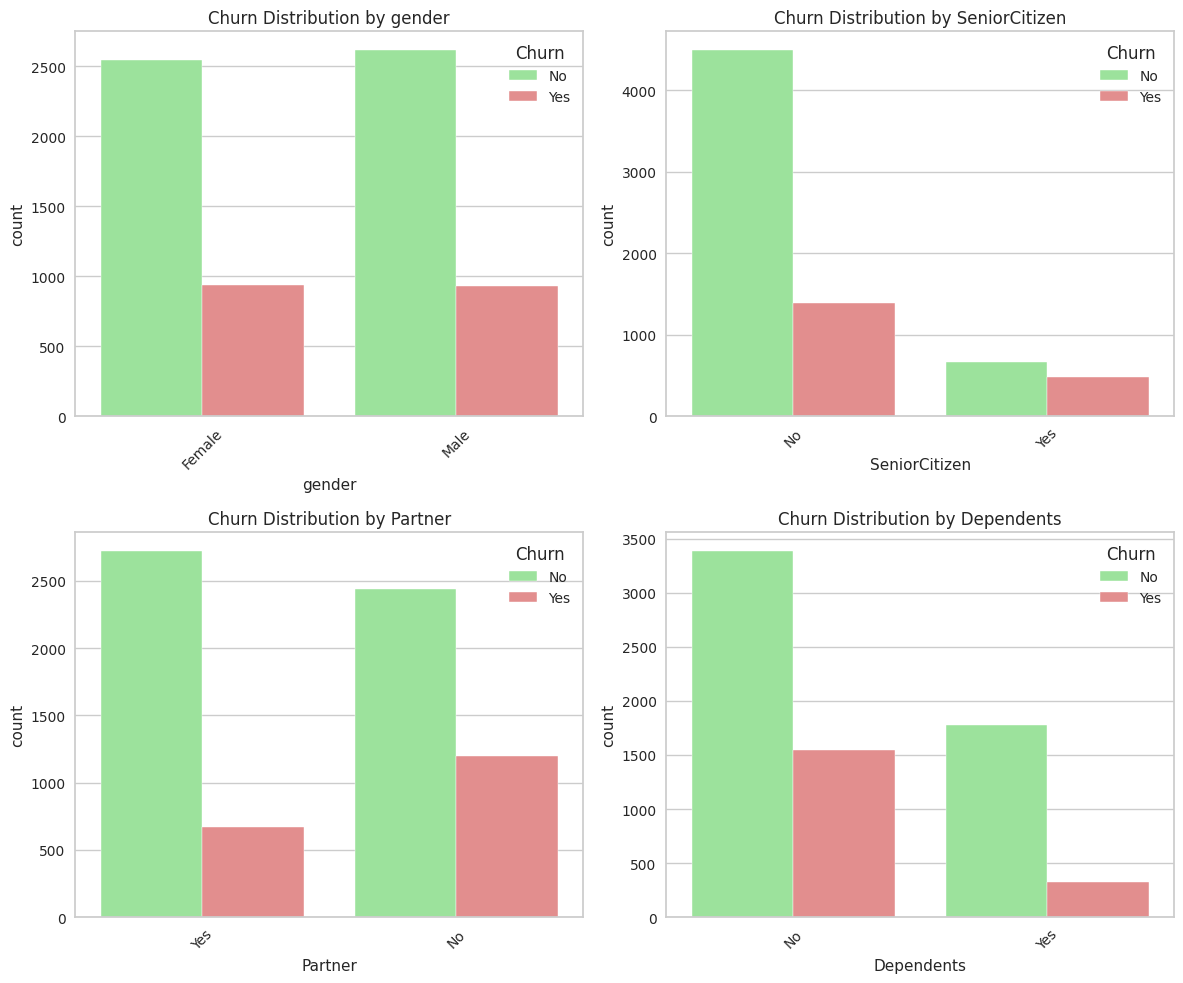

In [182]:
customer_demographic = ["gender", "SeniorCitizen", "Partner", "Dependents"]
countplots_for_categorical_features(df, customer_demographic, "Churn")

<span style="color:lime">

* The customer gender split is about 50/50 between males and females. no significant difference between gender and churn rate.

* Young customers are more likely to churn rather than old customers.

* Customers with a partner are less than churn if compared with a partner.
<span>

### Feature Processing & Engineering

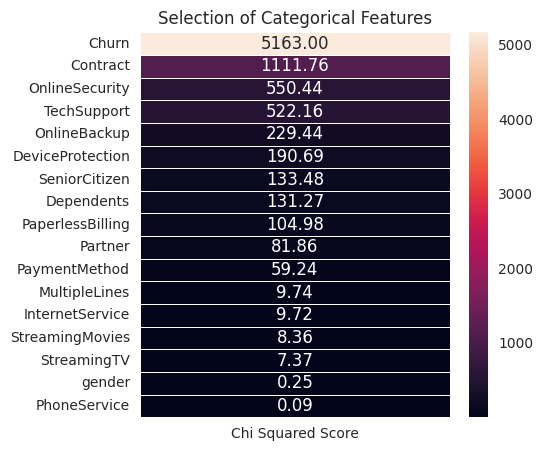

In [183]:
cat_columns = df.select_dtypes(include=object).columns

features = df[cat_columns]
features = OrdinalEncoder().fit_transform(features)
target = df['Churn'].map({'Yes': 1, 'No': 0})

best_features = SelectKBest(score_func = chi2, k = 'all')
fit = best_features.fit(features, target)

featureScores = pd.DataFrame(data = fit.scores_, index = cat_columns, columns = ['Chi Squared Score']) 

plt.subplots(figsize = (5,5))
sns.heatmap(
    featureScores.sort_values(ascending = False, by = 'Chi Squared Score'),
    annot = True,
    linewidths = 0.4,
    fmt = '.2f'
)
plt.title('Selection of Categorical Features')
plt.show()

The features Phoneservice, gender, StreamingTV, StreamingMovies, InternetService and Multiplelines have a very low Chi Sqaured score (less than 10) compared to other features. This suggests that they have little to no predictive power or relationship with the target variable. Hence these features will be dropped.

Not performing the ANOVA test for numerical columns as all the columns had a good correlation wiht the target as seen previously.

In [184]:
df.drop(columns=featureScores[featureScores['Chi Squared Score'] < 10].index.to_list(), inplace=True)

In [185]:
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes':1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [186]:
cat_columns = X.select_dtypes(include=object).columns
categorical_indices = [X.columns.get_loc(col) for col in cat_columns]

smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

X_train = pd.DataFrame(X_resampled, columns=X.columns)
y_train = pd.Series(y_resampled, name='Churn')

##### Save cleaned data

In [30]:
cleaned_train = X_train.copy()
cleaned_test = X_test.copy()

# Remapped back to 1 and 0, as given in the original data
cleaned_train['SeniorCitizen'] = cleaned_train['SeniorCitizen'].map({"Yes":1, "No":0})
cleaned_train['Churn'] = y_train

cleaned_test['SeniorCitizen'] = cleaned_test['SeniorCitizen'].map({"Yes":1, "No":0})
cleaned_test['Churn'] = y_test

if IS_LOCAL:
    cleaned_train.to_csv("../data/Telco-Customer-Churn-cleaned-train.csv", index=False)
    cleaned_test.to_csv("../data/Telco-Customer-Churn-cleaned-test.csv", index=False)
else:
    local_cleaned_train_path = "/tmp/Telco-Customer-Churn-cleaned-train.csv"
    local_cleaned_test_path = "/tmp/Telco-Customer-Churn-cleaned-test.csv"
    s3_clean_train_path = "data/Telco-Customer-Churn-cleaned-train.csv"
    s3_clean_test_path = "data/Telco-Customer-Churn-cleaned-test.csv"

    cleaned_train.to_csv(local_cleaned_train_path, index=False)
    cleaned_test.to_csv(local_cleaned_test_path, index=False)

    s3_client.upload_file(local_cleaned_train_path, bucket_name, s3_clean_train_path)
    s3_client.upload_file(local_cleaned_test_path, bucket_name, s3_clean_test_path)

In [31]:
if IS_LOCAL:
    train_df = X_train.copy()
    train_df['Churn'] = y_train

    clf_setup = setup(
        data=train_df,
        target='Churn',
        session_id=42,
        verbose=False
    )

    compare_models(sort='Recall', exclude=['lightgbm']);

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.8366,0.9061,0.8582,0.8228,0.8400,0.6731,0.6740,0.3180
ada,Ada Boost Classifier,0.8080,0.8914,0.8547,0.7819,0.8166,0.6160,0.6190,0.0920
gbc,Gradient Boosting Classifier,0.8170,0.9001,0.8492,0.7983,0.8227,0.6340,0.6357,0.1410
nb,Naive Bayes,0.7857,0.8704,0.8468,0.7549,0.7980,0.5714,0.5761,0.0520
lda,Linear Discriminant Analysis,0.7956,0.8861,0.8412,0.7711,0.8045,0.5911,0.5939,0.0500
ridge,Ridge Classifier,0.7954,0.8861,0.8409,0.7711,0.8043,0.5908,0.5935,0.0460
lr,Logistic Regression,0.8008,0.8892,0.8374,0.7806,0.8078,0.6015,0.6035,0.4900
rf,Random Forest Classifier,0.8276,0.9090,0.8309,0.8256,0.8282,0.6551,0.6553,0.1860
et,Extra Trees Classifier,0.8130,0.8938,0.8156,0.8115,0.8135,0.6261,0.6263,0.1510
knn,K Neighbors Classifier,0.7594,0.8325,0.8101,0.7357,0.7710,0.5189,0.5217,0.2200


In [187]:
# One hot encoding for categorical columns
cat_columns = X.select_dtypes(include=object).columns

# Create column transformer instance

transformer = make_column_transformer(
    (OneHotEncoder(drop='first', sparse_output=True), cat_columns),
    remainder='passthrough'
)

encoded_train = transformer.fit_transform(X_train[cat_columns])
encoded_test = transformer.transform(X_test[cat_columns])

encoded_train_df = pd.DataFrame.sparse.from_spmatrix(
    encoded_train,
    columns=transformer.get_feature_names_out(),
    index=X_train.index
    )

encoded_test_df = pd.DataFrame.sparse.from_spmatrix(
    encoded_test,
    columns=transformer.get_feature_names_out(),
    index=X_test.index
    )

In [188]:
encoded_train_df.columns = encoded_train_df.columns.str.replace('onehotencoder__', '')
encoded_test_df.columns = encoded_test_df.columns.str.replace('onehotencoder__', '')

In [189]:
num_columns = X.select_dtypes(include='number').columns

scaler = MinMaxScaler()

scaled_train = scaler.fit_transform(X_train[num_columns])
scaled_test = scaler.transform(X_test[num_columns])

# Create new DataFrames with the scaled values
scaled_train_df = pd.DataFrame(scaled_train, columns=num_columns, index=X_train.index)
scaled_test_df = pd.DataFrame(scaled_test, columns=num_columns, index=X_test.index)

In [190]:
X_train = pd.concat([scaled_train_df, encoded_train_df], axis=1)
X_test = pd.concat([scaled_test_df, encoded_test_df], axis=1)

### Training Models

#### Train Models

In [191]:
xgb = XGBClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42, algorithm='SAMME')
gbc = GradientBoostingClassifier(random_state=42)
gnb = GaussianNB()
lda = LinearDiscriminantAnalysis()
lr = LogisticRegression(random_state=42, n_jobs=-1)
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)

In [37]:
models = [
    ('XGBoost', xgb),
    ('AdaBoost', ada),
    ('Gradient Boosting', gbc),
    ('Gaussian Naive Bayes', gnb),
    ('Linear Discriminant Analysis', lda),
    ('Logistic Regression', lr),
    ('Random Forest', rfc)
]

k = 5

results = []

# Perform k-fold cross-validation for each model
for name, model in models:
    fresh_model = clone(model)
    kf = KFold(n_splits=k, shuffle=True, random_state=42)  # Create a KFold object
    cv_scores = cross_val_score(fresh_model, X_train, y_train, cv=kf, scoring='recall')  # Evaluate using accuracy
    print(f"{name} cross-validation complete. Mean recall-score: {cv_scores.mean():.4f}")

XGBoost cross-validation complete. Mean recall-score: 0.8605
AdaBoost cross-validation complete. Mean recall-score: 0.8185
Gradient Boosting cross-validation complete. Mean recall-score: 0.8469
Gaussian Naive Bayes cross-validation complete. Mean recall-score: 0.8489
Linear Discriminant Analysis cross-validation complete. Mean recall-score: 0.8411
Logistic Regression cross-validation complete. Mean recall-score: 0.8397
Random Forest cross-validation complete. Mean recall-score: 0.8387


In [38]:
# Initialize lists to store metrics
model_names_list = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = []

# Retrain the model on the full dataset after K-Fold Cross-Validation
for name, model in models:
    fresh_model = clone(model)
    fresh_model.fit(X_train, y_train)  # Train the model on the full dataset
    y_pred = fresh_model.predict(X_test)

    # Calculate accuracy, precision, recall, and F1-score

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, fresh_model.predict_proba(X_test)[:, 1])

    # Store model name and metrics
    model_names_list.append(name)
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)

    metrics_df = pd.DataFrame({
        'Model': model_names_list,
        'Accuracy': accuracy_scores,
        'Precision': precision_scores,
        'Recall': recall_scores,
        'F1-Score': f1_scores,
        'AUC': auc_scores,
    })

In [39]:
metrics_df.sort_values(by='Recall', ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,AUC
3,Gaussian Naive Bayes,0.720682,0.484245,0.780749,0.597748,0.811421
4,Linear Discriminant Analysis,0.732765,0.498239,0.756684,0.600849,0.817193
1,AdaBoost,0.734897,0.500891,0.751337,0.601070,0.823284
5,Logistic Regression,0.738451,0.505474,0.740642,0.600868,0.819693
2,Gradient Boosting,0.761194,0.537849,0.721925,0.616438,0.826017
0,XGBoost,0.744136,0.515217,0.633690,0.568345,0.798379
6,Random Forest,0.757640,0.541562,0.574866,0.557717,0.800502


### HyperParameter Tuning

After evaluating multiple classification models on key metrics like recall, F1-score, and AUC for the customer churn prediction task, I identified AdaBoost, Gradient Boosting, Gaussian Naive Bayes, and Linear Discriminant Analysis (LDA) as the top performers offering the best balance of performance and interpretability.

Gradient Boosting had the highest F1-score (0.6164) and AUC (0.8260), showing strong and consistent performance across all metrics.

AdaBoost followed closely with an F1-score of 0.6142 and AUC of 0.8231, and also offered a high recall (0.7513), making it very suitable for catching churners.

Gaussian Naive Bayes stood out for its highest recall (0.7807), ensuring most churners are flagged, despite slightly lower precision.

Linear Discriminant Analysis provided solid balance, with recall at 0.7567 and AUC of 0.8172, while being simpler and more interpretable than ensemble models.

As a result, only these models are selected for hyperparameter optimization moving forward.

In [40]:
param_space = {
    'AdaBoost': {
        'n_estimators': Integer(30, 200),
        'learning_rate': Real(1e-4, 1e+0, prior='log-uniform'),
    },
    'Gradient Boosting': {
        'n_estimators': Integer(300, 500),
        'learning_rate': Real(1e-4, 1e+0, prior='log-uniform'),
        'max_depth': Integer(3, 8),
    },
    'Gaussian Naive Bayes': {
        'var_smoothing': Real(1e-11, 1e-7, prior='log-uniform')
    },
    'Linear Discriminant Analysis': {
        'solver': Categorical(['lsqr', 'eigen']),
        'shrinkage': Categorical(['auto'])  # applicable only for lsqr/eigen
    },
    'Linear Discriminant Analysis 2': {
        'solver': Categorical(['svd']),
        'shrinkage': Categorical([None])  # applicable only for lsqr/eigen
    }
}

In [41]:
best_models = {}

selected_models = [
    ('AdaBoost', clone(ada)),
    ('Gradient Boosting', clone(gbc)),
    ('Gaussian Naive Bayes', clone(gnb)),
    ('Linear Discriminant Analysis', clone(lda)),
    ('Linear Discriminant Analysis 2', clone(lda)),
]

for name, model in selected_models:
    
    # Perform BayesSearchCV to tune hyperparameters
    print(f"Performing BayesSearchCV for {name}...")
    
    opt = BayesSearchCV(
        model,
        param_space[name],
        scoring='f1',  # recall score optimization
        n_jobs=-1,
        random_state=42,
        n_iter=100
    )

    
    opt.fit(X_train, y_train)
    
    # Save the best model after hyperparameter tuning
    best_models[name] = opt.best_estimator_
    
    # Print the best hyperparameters and performance
    print(f"Best Hyperparameters for {name}: {opt.best_params_}")
    print(f"Best Cross-Validated Recall for {name}: {opt.best_score_}", end='\n')


Performing BayesSearchCV for AdaBoost...
Best Hyperparameters for AdaBoost: OrderedDict([('learning_rate', 0.8595807276060273), ('n_estimators', 126)])
Best Cross-Validated Recall for AdaBoost: 0.8150740168329236
Performing BayesSearchCV for Gradient Boosting...
Best Hyperparameters for Gradient Boosting: OrderedDict([('learning_rate', 0.029492655124203206), ('max_depth', 7), ('n_estimators', 500)])
Best Cross-Validated Recall for Gradient Boosting: 0.8345404256812798
Performing BayesSearchCV for Gaussian Naive Bayes...
Best Hyperparameters for Gaussian Naive Bayes: OrderedDict([('var_smoothing', 4.3693399475103194e-10)])
Best Cross-Validated Recall for Gaussian Naive Bayes: 0.7885319625051935
Performing BayesSearchCV for Linear Discriminant Analysis...
Best Hyperparameters for Linear Discriminant Analysis: OrderedDict([('shrinkage', 'auto'), ('solver', 'eigen')])
Best Cross-Validated Recall for Linear Discriminant Analysis: 0.802310375216772
Performing BayesSearchCV for Linear Discrim

In [ ]:
model_names_list = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = []

# Loop through each best model and evaluate on test data
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # If model has predict_proba (for AUC)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Use decision_function if available
        y_proba = model.decision_function(X_test)
    
    # Append all metrics
    model_names_list.append(name)
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))


best_metrics_df = pd.DataFrame({
    'Model': model_names_list,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores,
    'AUC': auc_scores,
})

best_metrics_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,AdaBoost,0.737740,0.504409,0.764706,0.607864,0.827835
1,Linear Discriminant Analysis,0.734186,0.500000,0.759358,0.602972,0.817266
2,Linear Discriminant Analysis 2,0.732765,0.498239,0.756684,0.600849,0.817193
3,Gaussian Naive Bayes,0.720682,0.484245,0.780749,0.597748,0.811421
4,Gradient Boosting,0.764748,0.550351,0.628342,0.586767,0.809651


From the above optimizations, I think the best model for the given task is AdaBoost, with the highest F1 score and recall.

In [ ]:
from joblib import dump

best_model_name = 'AdaBoost'
final_model = best_models[best_model_name]

if IS_LOCAL:
    if not os.path.exists("../models"):
        os.mkdir("../models")

    dump(final_model, f'../models/{best_model_name}.joblib');

### Prediction and Plots

In [212]:
y_pred = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

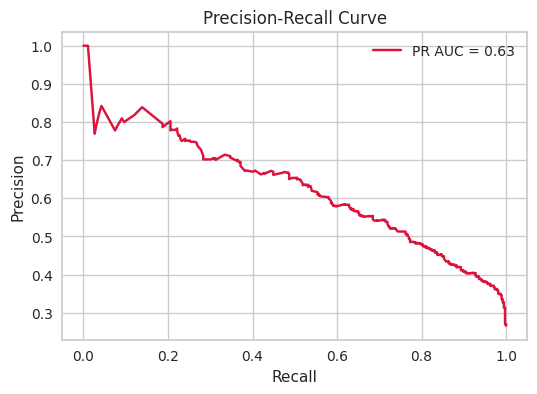

In [221]:
# Compute Precision-Recall curve and AUC
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Calculate the Area Under the Curve (AUC)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='crimson', label=f'PR AUC = {pr_auc:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

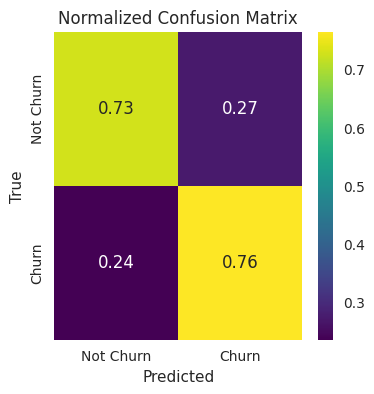

In [231]:
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='viridis',
    xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn']
    )
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

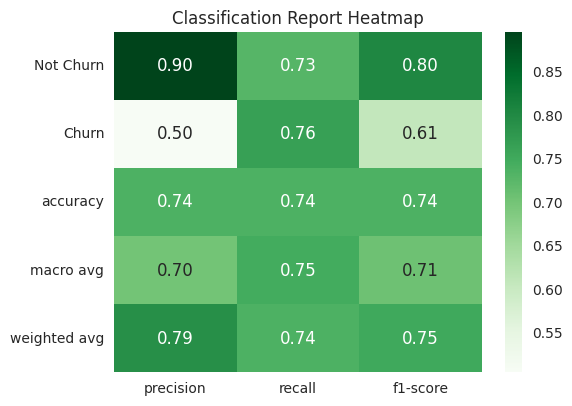

In [232]:
clf_report = classification_report(y_test, y_pred, labels = [0, 1],
                                   target_names= ["Not Churn", "Churn"], output_dict=True
                                   )
report_df = pd.DataFrame(clf_report).iloc[:-1, :].T  # Excluding 'support'

plt.figure(figsize=(6, 4))
sns.heatmap(report_df, annot=True, fmt='.2f', cmap='Greens', cbar=True)

plt.yticks(rotation=0)
plt.tight_layout()
plt.title('Classification Report Heatmap')
plt.show()

In [230]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")

Precision: 0.5044
Recall: 0.7647
Accuracy: 0.7377
AUC: 0.8278
